FEATURE EXTRACTION

In [1]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import librosa
import math
from matplotlib.ticker import FormatStrFormatter

In [2]:
# 1. Definizione del percorso del file
CSV_INPUT_PATH = "audio_samples_metadata.csv"
INPUT_AUDIO_DIR = Path("AudioSamplesPreprocessed")
NOISE_PATH = "noise.wav"

CARICAMENTO DATI

In [3]:
def load_audio_data(csv_input_path):
    audio_df=pd.DataFrame()
    # 2. Caricamento del file CSV nel DataFrame
    if Path(csv_input_path).exists():
        audio_df = pd.read_csv(csv_input_path)
        
        # Conversione della colonna timestamp in oggetti datetime
        audio_df["timestamp"] = pd.to_datetime(audio_df["timestamp"])
        
        print("File CSV caricato correttamente.")
        print(f"Numero di righe lette: {len(audio_df)}")
        
        # Visualizzazione delle prime righe e dei tipi di dati
        print("\nAnteprima del DataFrame:")
        print(audio_df.head())
        print("\nInformazioni sulle colonne:")
        print(audio_df.info())
    else:
        print(f"Errore: Il file {csv_input_path} non esiste nella directory corrente.")

    return audio_df

audiofiles_df = load_audio_data(CSV_INPUT_PATH)

File CSV caricato correttamente.
Numero di righe lette: 1389

Anteprima del DataFrame:
                                   original_filename  \
0  audio_548329df66f2be5cebe3a3ab8688da8658eefb65...   
1  audio_4308ece211efbbe098f438474dffb8efb1517af2...   
2  audio_be49fb71e4c2a540ba07d72d6d59d423ad4e15bd...   
3  audio_bf2de73f90b6f7dd200b4a58d1e8ac2f7186900a...   
4  audio_5919f6a394c4aa055ae46794683e94673cee6288...   

                                            filename           timestamp  \
0  audio_548329df66f2be5cebe3a3ab8688da8658eefb65... 2026-03-09 15:34:22   
1  audio_4308ece211efbbe098f438474dffb8efb1517af2... 2026-03-09 15:39:28   
2  audio_be49fb71e4c2a540ba07d72d6d59d423ad4e15bd... 2026-03-09 15:41:41   
3  audio_bf2de73f90b6f7dd200b4a58d1e8ac2f7186900a... 2026-03-09 15:46:47   
4  audio_5919f6a394c4aa055ae46794683e94673cee6288... 2026-03-09 15:51:54   

   snr_before_cleaning  
0            -0.680045  
1            -0.660743  
2            -0.662686  
3            -0.672

In [4]:
# Ordinamento decrescente per timestamp e visualizzazione delle prime 10 righe
#print(audiofiles_df.sort_values(by='timestamp', ascending=False).head(10))

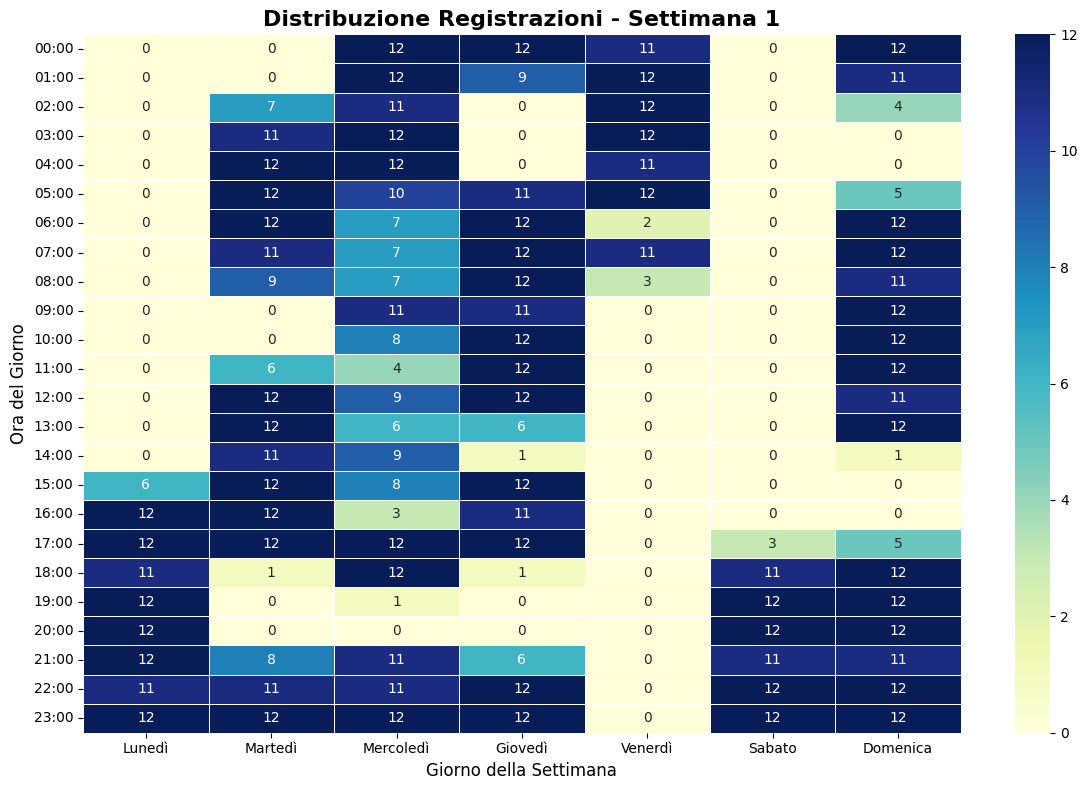

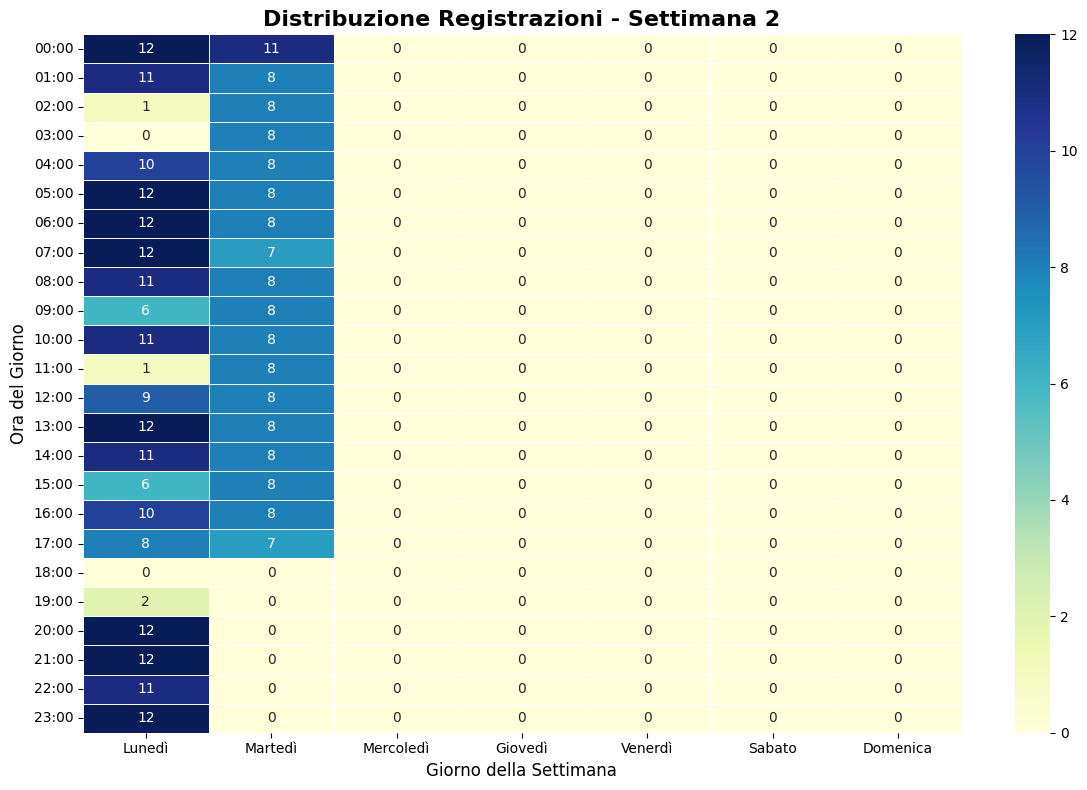

In [ ]:
def plot_registration_scheduling(audio_df):
    # 1. Copia e preparazione dati
    df = audio_df.copy()
    
    # Assicuriamoci che sia datetime
    df['timestamp'] = pd.to_datetime(df['timestamp'])
    
    # 2. Calcolo della "Settimana Relativa"
    start_date = df['timestamp'].min() - pd.to_timedelta(df['timestamp'].min().dayofweek, unit='D')
    start_date = start_date.replace(hour=0, minute=0, second=0, microsecond=0)
    
    df['week_num'] = ((df['timestamp'] - start_date).dt.days // 7) + 1
    df['week_label'] = "Settimana " + df['week_num'].astype(str)
    
    # 3. Traduzione e Formattazione
    traduzione_giorni = {
        'Monday': 'Lunedì', 'Tuesday': 'Martedì', 'Wednesday': 'Mercoledì',
        'Thursday': 'Giovedì', 'Friday': 'Venerdì', 'Saturday': 'Sabato', 'Sunday': 'Domenica'
    }
    
    df['day_name'] = df['timestamp'].dt.day_name().map(traduzione_giorni)
    df['hour_label'] = df['timestamp'].dt.hour.astype(str).str.zfill(2) + ":00"
    
    # Ordinamento assi
    giorni_it = ['Lunedì', 'Martedì', 'Mercoledì', 'Giovedì', 'Venerdì', 'Sabato', 'Domenica']
    ore_ordinate = [f"{str(i).zfill(2)}:00" for i in range(24)]
    
    # Otteniamo la lista delle settimane uniche ordinate cronologicamente
    settimane_presenti = sorted(df['week_label'].unique(), key=lambda x: int(x.split()[1]))

    # 4. Ciclo per generare un'immagine per SETTIMANA
    for settimana in settimane_presenti:
        # Filtriamo il DataFrame solo per la settimana corrente
        df_settimana = df[df['week_label'] == settimana]
        
        # Creiamo la pivot table specifica per questa settimana
        pivot = df_settimana.pivot_table(index='hour_label', 
                                         columns='day_name', 
                                         values='filename', 
                                         aggfunc='count')
        
        # Reindex per garantire la struttura completa 24x7
        pivot = pivot.reindex(index=ore_ordinate, columns=giorni_it).fillna(0)
        
        # --- Creazione della Figura Separata ---
        plt.figure(figsize=(12, 8)) # Dimensione della singola immagine
        
        sns.heatmap(pivot, annot=True, fmt='g', cmap="YlGnBu", cbar=True, linewidths=.5)
        
        plt.title(f'Distribuzione Registrazioni - {settimana}', fontsize=16, weight='bold')
        plt.xlabel('Giorno della Settimana', fontsize=12)
        plt.ylabel('Ora del Giorno', fontsize=12)
        
        plt.tight_layout()
        
        plt.show()


plot_registration_scheduling(audiofiles_df)

GENERAL PARAMETERS

In [6]:
SAMPLE_RATE = 16000   #16 kHz
FRAME_SIZE = 1024
HOP_LENGTH = 512
BASE_SPLIT_FREQUENCY = 2000


def plot_audio_signal(signal, sample_rate, title="Audio Signal"):
    plt.figure(figsize=(25, 10))

    # Visualizzazione della forma d'onda
    librosa.display.waveshow(signal, sr=sample_rate, alpha=0.5)

    # Configurazione delle etichette degli assi
    plt.xlabel("Time (seconds)")
    plt.ylabel("Amplitude")

    # Opzionale: aggiunta di una griglia per migliorare la leggibilità
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.ylim((-1, 1))
    plt.title(title)
    plt.show()

AMPLITUDE ENVELOPE

In [7]:
def amplitude_envelope(signal, frame_size, hop_length):
    """Calculate the amplitude envelope of a signal with a given frame size and hop length."""
    amplitude_envelope = []
    
    # calculate amplitude envelope for each frame
    for i in range(0, len(signal), hop_length): 
        amplitude_envelope_current_frame = max(signal[i:i+frame_size])
        amplitude_envelope.append(amplitude_envelope_current_frame)
    
    return np.array(amplitude_envelope)

def plot_amplitude_envelope(signal, ae_signal, hop_length, sample_rate):
    frames = range(len(ae_signal))
    t = librosa.frames_to_time(frames, hop_length=hop_length, sr=sample_rate)
    # amplitude envelope is graphed in red

    plt.figure(figsize=(15, 17))

    ax = plt.subplot(3, 1, 1)
    librosa.display.waveshow(signal, alpha=0.5, sr=sample_rate)
    plt.plot(t, ae_signal, color="r")
    plt.ylim((-1, 1))
    plt.xlabel('Time (seconds)')
    plt.ylabel('Amplitude')
    plt.title("Amplitude Envelope")

    plt.show()

In [8]:
# number of frames in amplitude envelope
# ae_audio_signal = amplitude_envelope(audio_signal, FRAME_SIZE, HOP_LENGTH)

#plot_amplitude_envelope(audio_signal, ae_audio_signal, HOP_LENGTH, SAMPLE_RATE)

RMSE

In [9]:
def rmse(signal, frame_size, hop_length):
    return librosa.feature.rms(y=signal, frame_length=frame_size, hop_length=hop_length)[0]

def plot_rmse(signal, rms_signal, hop_length, sample_rate):
    frames = range(len(rms_signal))
    t = librosa.frames_to_time(frames, hop_length=hop_length, sr=sample_rate)
    # rms energy is graphed in red

    plt.figure(figsize=(15, 17))

    ax = plt.subplot(3, 1, 1)
    librosa.display.waveshow(signal, alpha=0.5, sr=sample_rate)
    plt.plot(t, rms_signal, color="r")
    plt.ylim((-1, 1))
    plt.xlabel('Time (seconds)')
    plt.ylabel('Amplitude')
    plt.title("RMS Energy")

    plt.show()

In [10]:
#rms_audio_signal = rmse(audio_signal, FRAME_SIZE, HOP_LENGTH)

#plot_rmse(audio_signal, rms_audio_signal, HOP_LENGTH, SAMPLE_RATE)

ZERO-CROSSING RATE

In [11]:
def zero_crossing_rate(signal, frame_size, hop_length):
    return librosa.feature.zero_crossing_rate(y=signal, frame_length=frame_size, hop_length=hop_length)[0]

def plot_zero_crossing_rate(zcr_signal, hop_length, sample_rate):
    frames=range(len(zcr_signal))
    t = librosa.frames_to_time(frames, hop_length=hop_length, sr=sample_rate)
    plt.figure(figsize=(15, 5))

    plt.plot(t, zcr_signal, color="r")
    plt.xlabel('Time (seconds)')
    plt.ylabel('Zero Crossing Rate')
    plt.ylim(0, 1)
    plt.title("Zero Crossing Rate")
    plt.show()

In [12]:
#zcr_audio_signal = zero_crossing_rate(audio_signal, FRAME_SIZE, HOP_LENGTH)

#plot_zero_crossing_rate(zcr_audio_signal, HOP_LENGTH, SAMPLE_RATE)

FOURIER TRANSFORM

In [13]:
def magnitude_spectrum(signal):
    X = np.fft.fft(signal)
    X_mag = np.absolute(X)
    half = len(X_mag) // 2
    X_mag_half = X_mag[:half]
    return X_mag_half

def plot_magnitude_spectrum(signal, sr, title):
    X_mag = magnitude_spectrum(signal)
    
    plt.figure(figsize=(18, 5))
    
    f = np.linspace(0, sr, len(X_mag)) 
    
    plt.plot(f, X_mag)
    plt.xlabel('Frequency (Hz)')
    plt.ylabel('Magnitude')
    plt.title(title)

In [14]:
#plot_magnitude_spectrum(audio_signal, SAMPLE_RATE, "Audio signal")

SPECTOGRAM

In [15]:
def spectrogram(signal, frame_size, hop_length):
    S_scale = librosa.stft(signal, n_fft=frame_size, hop_length=hop_length)
    Y_scale = np.abs(S_scale) ** 2
    Y_log_scale = librosa.power_to_db(Y_scale)
    return Y_log_scale

def plot_spectrogram(Y, sr, hop_length, y_axis="linear"):
    plt.figure(figsize=(25, 10))
    librosa.display.specshow(Y, 
                             sr=sr, 
                             hop_length=hop_length, 
                             x_axis="time", 
                             y_axis=y_axis)
    plt.xlabel("Time (seconds)")
    plt.ylabel("Mel frequency" if y_axis == "mel" else "Frequency (Hz)")
    if y_axis in ["mel", "log"]:
        formatter = FormatStrFormatter('%+2.0f dB')
    else:
        formatter = FormatStrFormatter('%+2.0f')
    plt.colorbar(format=formatter).set_label("Magnitude", rotation=90, labelpad=15)
    plt.title(f"{'Mel ' if y_axis == 'mel' else ''}Spectrogram")

In [16]:
#audio_signal_spectrogram = spectrogram(audio_signal, FRAME_SIZE, HOP_LENGTH)
#plot_spectrogram(audio_signal_spectrogram, SAMPLE_RATE, HOP_LENGTH, y_axis="log")

MEL SPECTROGRAM

In [17]:
def mel_spectrogram(signal, frame_size, hop_length, sr, n_mels):
    mel_spectrogram = librosa.feature.melspectrogram(y=signal, sr=sr, n_fft=frame_size, hop_length=hop_length, n_mels=n_mels)
    log_mel_spectrogram = librosa.power_to_db(mel_spectrogram)
    return log_mel_spectrogram

'''
filter_banks = librosa.filters.mel(n_fft=FRAME_SIZE, sr=sample_rate, n_mels=10)

plt.figure(figsize=(25, 10))
librosa.display.specshow(filter_banks, 
                         sr=sample_rate, 
                         x_axis="linear")
plt.colorbar(format="%+2.f")
plt.show()
'''

'\nfilter_banks = librosa.filters.mel(n_fft=FRAME_SIZE, sr=sample_rate, n_mels=10)\n\nplt.figure(figsize=(25, 10))\nlibrosa.display.specshow(filter_banks, \n                         sr=sample_rate, \n                         x_axis="linear")\nplt.colorbar(format="%+2.f")\nplt.show()\n'

In [18]:
#audio_signal_mel_spectrogram = mel_spectrogram(audio_signal, FRAME_SIZE, HOP_LENGTH, SAMPLE_RATE, n_mels=10)

#plot_spectrogram(audio_signal_mel_spectrogram, SAMPLE_RATE, HOP_LENGTH, y_axis="mel")

MFCC

In [19]:
def mfcc(signal, sr, n_mfcc):
    mfccs = librosa.feature.mfcc(y=signal, sr=sr, n_mfcc=n_mfcc)
    return mfccs

def mfcc_delta(mfccs, order=1):
    delta_mfccs = librosa.feature.delta(mfccs, order=order)
    return delta_mfccs

def plot_mfcc(mfccs, sr, hop_length, ylabel="MFCC", title="MFCC"):
    plt.figure(figsize=(25, 10))
    librosa.display.specshow(mfccs, 
                            x_axis="time", 
                            sr=sr,
                            hop_length=hop_length
                            )
    plt.colorbar(format="%+2.f")
    plt.xlabel('Time (seconds)')
    plt.ylabel(ylabel)
    plt.title(title)
    plt.show()

In [20]:
'''
mfccs = mfcc(audio_signal, SAMPLE_RATE, n_mfcc=13)

delta_mfccs = mfcc_delta(mfccs)

delta2_mfccs = mfcc_delta(mfccs, order=2)

plot_mfcc(mfccs, SAMPLE_RATE, HOP_LENGTH)
plot_mfcc(delta_mfccs, SAMPLE_RATE, HOP_LENGTH, ylabel="Δ MFCC")
plot_mfcc(delta2_mfccs, SAMPLE_RATE, HOP_LENGTH, ylabel="Δ² MFCC")

mfccs_features = np.concatenate((mfccs, delta_mfccs, delta2_mfccs))
'''

'\nmfccs = mfcc(audio_signal, SAMPLE_RATE, n_mfcc=13)\n\ndelta_mfccs = mfcc_delta(mfccs)\n\ndelta2_mfccs = mfcc_delta(mfccs, order=2)\n\nplot_mfcc(mfccs, SAMPLE_RATE, HOP_LENGTH)\nplot_mfcc(delta_mfccs, SAMPLE_RATE, HOP_LENGTH, ylabel="Δ MFCC")\nplot_mfcc(delta2_mfccs, SAMPLE_RATE, HOP_LENGTH, ylabel="Δ² MFCC")\n\nmfccs_features = np.concatenate((mfccs, delta_mfccs, delta2_mfccs))\n'

BAND ENERGY RATIO

In [21]:
def calculate_split_frequency_bin(split_frequency, sample_rate, num_frequency_bins):
    """Infer the frequency bin associated to a given split frequency."""
    
    frequency_range = sample_rate / 2
    frequency_delta_per_bin = frequency_range / num_frequency_bins
    split_frequency_bin = math.floor(split_frequency / frequency_delta_per_bin)
    return int(split_frequency_bin)

def band_energy_ratio(signal,split_frequency, frame_size, hop_length, sample_rate):
    """Calculate band energy ratio with a given split frequency."""

    spectrogram = librosa.stft(signal, n_fft=frame_size, hop_length=hop_length)

    split_frequency_bin = calculate_split_frequency_bin(split_frequency, sample_rate, spectrogram.shape[0])
    band_energy_ratio = []
    
    # calculate power spectrogram
    power_spectrogram = np.abs(spectrogram) ** 2
    power_spectrogram = power_spectrogram.T
    
    # calculate BER value for each frame
    for frame in power_spectrogram:
        sum_power_low_frequencies = frame[:split_frequency_bin].sum()
        sum_power_high_frequencies = frame[split_frequency_bin:].sum()
        band_energy_ratio_current_frame = sum_power_low_frequencies / sum_power_high_frequencies
        band_energy_ratio.append(band_energy_ratio_current_frame)
    
    return np.array(band_energy_ratio)

def plot_band_energy_ratio(ber_signal, hop_length, sample_rate):
    frames = range(len(ber_signal))
    t = librosa.frames_to_time(frames, hop_length=hop_length, sr=sample_rate)
    plt.figure(figsize=(25, 10))

    plt.plot(t, ber_signal, color="b")
    #plt.ylim((0, 4000000))
    plt.xlabel('Time (seconds)')
    plt.ylabel('Band Energy Ratio')
    plt.title("Band Energy Ratio")
    plt.show()


In [22]:
#ber_audio_signal = band_energy_ratio(audio_signal, BASE_SPLIT_FREQUENCY, FRAME_SIZE, HOP_LENGTH, SAMPLE_RATE)

#plot_band_energy_ratio(ber_audio_signal, HOP_LENGTH, SAMPLE_RATE)

SPECTRAL CENTROID

In [23]:
def spectral_centroid(signal, sr, frame_size, hop_length):
    return librosa.feature.spectral_centroid(y=signal, sr=sr, n_fft=frame_size, hop_length=hop_length)[0]

def plot_spectral_centroid(sc_signal, hop_length, sample_rate):
    frames = range(len(sc_signal))
    t = librosa.frames_to_time(frames, hop_length=hop_length, sr=sample_rate)
    plt.figure(figsize=(25,10))

    plt.plot(t, sc_signal, color='b')
    plt.xlabel('Time (seconds)')
    plt.ylabel('Spectral Centroid')
    plt.title("Spectral Centroid")
    plt.show()

In [24]:
#sc_audio_signal = spectral_centroid(audio_signal, SAMPLE_RATE, FRAME_SIZE, HOP_LENGTH)

#plot_spectral_centroid(sc_audio_signal, HOP_LENGTH, SAMPLE_RATE)

SPECTRAL BANDWITH

In [25]:
def spectral_bandwidth(signal, sr, frame_size, hop_length):
    return librosa.feature.spectral_bandwidth(y=signal, sr=sr, n_fft=frame_size, hop_length=hop_length)[0]

def plot_spectral_bandwidth(bandwidth_signal, hop_length, sample_rate):

    frames = range(len(bandwidth_signal))
    t = librosa.frames_to_time(frames, hop_length=hop_length, sr=sample_rate)
    plt.figure(figsize=(25,10))

    plt.plot(t, bandwidth_signal, color='b')
    plt.xlabel('Time (seconds)')
    plt.ylabel('Spectral Bandwidth')
    plt.title("Spectral Bandwidth")
    plt.show()

In [26]:
#bandwidth_audio_signal = spectral_bandwidth(audio_signal, SAMPLE_RATE, FRAME_SIZE, HOP_LENGTH)

#plot_spectral_bandwidth(bandwidth_audio_signal, HOP_LENGTH, SAMPLE_RATE)

ANALISI FILE AUDIO

In [ ]:
audio_signals_metrics=[]
#noise_signal, noise_sr = librosa.load(NOISE_PATH, sr=SAMPLE_RATE)

for index, row in audiofiles_df.iterrows():

    filename = row["filename"]

    # 2. Costruiamo il percorso completo (AudioSamples/nome_file.wav)
    file_path = INPUT_AUDIO_DIR / filename

    # 3. Carichiamo l'audio con librosa
    audio_signal, sr = librosa.load(file_path, sr=SAMPLE_RATE)

    print(f"File caricato: {file_path} (timestamp: {row['timestamp']})")
    #print(f"Frequenza di campionamento (SR): {sr} Hz")
    #print(f"Durata: {librosa.get_duration(y=raw_audio_signal, sr=sr):.2f} secondi")
    #print(f"Timestamp del file: {row['timestamp']}")
    
    ae_audio_signal = amplitude_envelope(audio_signal, FRAME_SIZE, HOP_LENGTH)
    rms_audio_signal = rmse(audio_signal, FRAME_SIZE, HOP_LENGTH)
    zcr_audio_signal = zero_crossing_rate(audio_signal, FRAME_SIZE, HOP_LENGTH)
    magnitude_spectrum_audio_signal = magnitude_spectrum(audio_signal)
    spectrogram_audio_signal = spectrogram(audio_signal, FRAME_SIZE, HOP_LENGTH)
    mel_spectrogram_audio_signal = mel_spectrogram(audio_signal, FRAME_SIZE, HOP_LENGTH, SAMPLE_RATE, n_mels=10)
    mfccs = mfcc(audio_signal, SAMPLE_RATE, n_mfcc=13)
    delta_mfccs = mfcc_delta(mfccs)
    delta2_mfccs = mfcc_delta(mfccs, order=2)
    ber_audio_signal = band_energy_ratio(audio_signal, BASE_SPLIT_FREQUENCY, FRAME_SIZE, HOP_LENGTH, SAMPLE_RATE)
    sc_audio_signal = spectral_centroid(audio_signal, SAMPLE_RATE, FRAME_SIZE, HOP_LENGTH)
    bandwidth_audio_signal = spectral_bandwidth(audio_signal, SAMPLE_RATE, FRAME_SIZE, HOP_LENGTH)
    audio_signals_metrics.append({
        "filename": filename,
        "amplitude_envelope": ae_audio_signal,
        "rms_energy": rms_audio_signal,
        "zero_crossing_rate": zcr_audio_signal,
        "magnitude_spectrum": magnitude_spectrum_audio_signal,
        "spectrogram": spectrogram_audio_signal,
        "mel_spectrogram": mel_spectrogram_audio_signal,
        "mfccs": mfccs,
        "delta_mfccs": delta_mfccs,
        "delta2_mfccs": delta2_mfccs,
        "band_energy_ratio": ber_audio_signal,
        "spectral_centroid": sc_audio_signal,
        "spectral_bandwidth": bandwidth_audio_signal,
    })


File caricato: AudioSamplesPreprocessed\audio_548329df66f2be5cebe3a3ab8688da8658eefb653bb0d37c1c52dc30049b7f2f.wav (timestamp: 2026-03-09 15:34:22)
File caricato: AudioSamplesPreprocessed\audio_4308ece211efbbe098f438474dffb8efb1517af2e8fa7c8249f6a4b2a00082be.wav (timestamp: 2026-03-09 15:39:28)
File caricato: AudioSamplesPreprocessed\audio_be49fb71e4c2a540ba07d72d6d59d423ad4e15bd7177573158ed508d1755bf89.wav (timestamp: 2026-03-09 15:41:41)
File caricato: AudioSamplesPreprocessed\audio_bf2de73f90b6f7dd200b4a58d1e8ac2f7186900a35f8d3008699f6c5aa9745f3.wav (timestamp: 2026-03-09 15:46:47)
File caricato: AudioSamplesPreprocessed\audio_5919f6a394c4aa055ae46794683e94673cee6288eee3609bbb985f1b286d92ca.wav (timestamp: 2026-03-09 15:51:54)
File caricato: AudioSamplesPreprocessed\audio_fffdb5d3721332d48f2a73d0ff531aa16961ea0c71e712320b8423789b2c07ed.wav (timestamp: 2026-03-09 15:57:01)
File caricato: AudioSamplesPreprocessed\audio_4b18ffc1dbec674e4f60467e43bf3139ef8f31f7ab2df256be90061358b5d756.w

In [28]:
'''
# 1. Trasformazione della lista di dizionari in un DataFrame di medie
# (Necessario perché metriche come RMS o Centroid sono array temporali)
rows = []
for entry in audio_signals_metrics:
    row = {
        "filename": entry["filename"],
        "RMS Energy": np.mean(entry["rms_energy"]),
        "Zero Crossing Rate": np.mean(entry["zero_crossing_rate"]),
        "Amplitude Envelope": np.mean(entry["amplitude_envelope"]),
        "Spectral Centroid": np.mean(entry["spectral_centroid"]),
        "Spectral Bandwidth": np.mean(entry["spectral_bandwidth"]),
        "Band Energy Ratio": np.mean(entry["band_energy_ratio"])
    }
    rows.append(row)

df_stats = pd.DataFrame(rows)
'''
'''
# 2. Configurazione dello stile estetico
sns.set_theme(style="whitegrid")

# 3. Trasformazione del DF in formato "Long" per la visualizzazione a griglia
df_long = df_stats.melt(id_vars="filename", var_name="Metric", value_name="Value")

# 4. Creazione della FacetGrid (una griglia di grafici)
# col_wrap=3 crea una griglia con 3 colonne
g = sns.FacetGrid(df_long, col="Metric", col_wrap=3, sharey=False, sharex=False, height=4, aspect=1.2)

# 5. Mapping del grafico di densità (KDE) su ogni sottografo
g.map(sns.kdeplot, "Value", fill=True, color="royalblue", alpha=0.6, linewidth=2)

# 6. Personalizzazione finale dei titoli e dei margini
g.set_titles("{col_name}", size=14, weight='bold')
plt.subplots_adjust(top=0.9)
g.fig.suptitle('Distribuzione Statistica delle Metriche Audio tra i vari chunk', size=18, y=1.02)

plt.show()

# 7. (Opzionale) Visualizzazione della tabella riassuntiva (media, deviazione standard, etc.)
print("\nStatistiche descrittive del dataset:")
print(df_stats.describe().T)
'''
'''
units = {
    "RMS Energy": "Ampiezza (Lineare)",
    "Zero Crossing Rate": "Rateo (0.0 - 1.0)",
    "Amplitude Envelope": "Ampiezza (Lineare)",
    "Spectral Centroid": "Frequenza (Hz)",
    "Spectral Bandwidth": "Frequenza (Hz)",
    "Band Energy Ratio": "Rapporto (Adimensionale)"
}
# Impostazioni estetiche
sns.set_theme(style="whitegrid")
metrics = list(units.keys())
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(14, 12))
axes = axes.flatten()

for i, col in enumerate(metrics):
    sns.histplot(df_stats[col], kde=True, ax=axes[i], color="skyblue", edgecolor="black")
    axes[i].set_title(f"Distribuzione di {col}")
    axes[i].set_xlabel(units[col])
    axes[i].set_ylabel("Frequenza (Conteggio)")

plt.tight_layout()
plt.show()
'''

'\nunits = {\n    "RMS Energy": "Ampiezza (Lineare)",\n    "Zero Crossing Rate": "Rateo (0.0 - 1.0)",\n    "Amplitude Envelope": "Ampiezza (Lineare)",\n    "Spectral Centroid": "Frequenza (Hz)",\n    "Spectral Bandwidth": "Frequenza (Hz)",\n    "Band Energy Ratio": "Rapporto (Adimensionale)"\n}\n# Impostazioni estetiche\nsns.set_theme(style="whitegrid")\nmetrics = list(units.keys())\nfig, axes = plt.subplots(nrows=3, ncols=2, figsize=(14, 12))\naxes = axes.flatten()\n\nfor i, col in enumerate(metrics):\n    sns.histplot(df_stats[col], kde=True, ax=axes[i], color="skyblue", edgecolor="black")\n    axes[i].set_title(f"Distribuzione di {col}")\n    axes[i].set_xlabel(units[col])\n    axes[i].set_ylabel("Frequenza (Conteggio)")\n\nplt.tight_layout()\nplt.show()\n'

Analisi del file: audio_4cb86ddcae1ccc8287cb57e16b842cb83468dcd4df0872bef283b71260cc8979.wav con timestamp: 2026-03-09 22:25:31


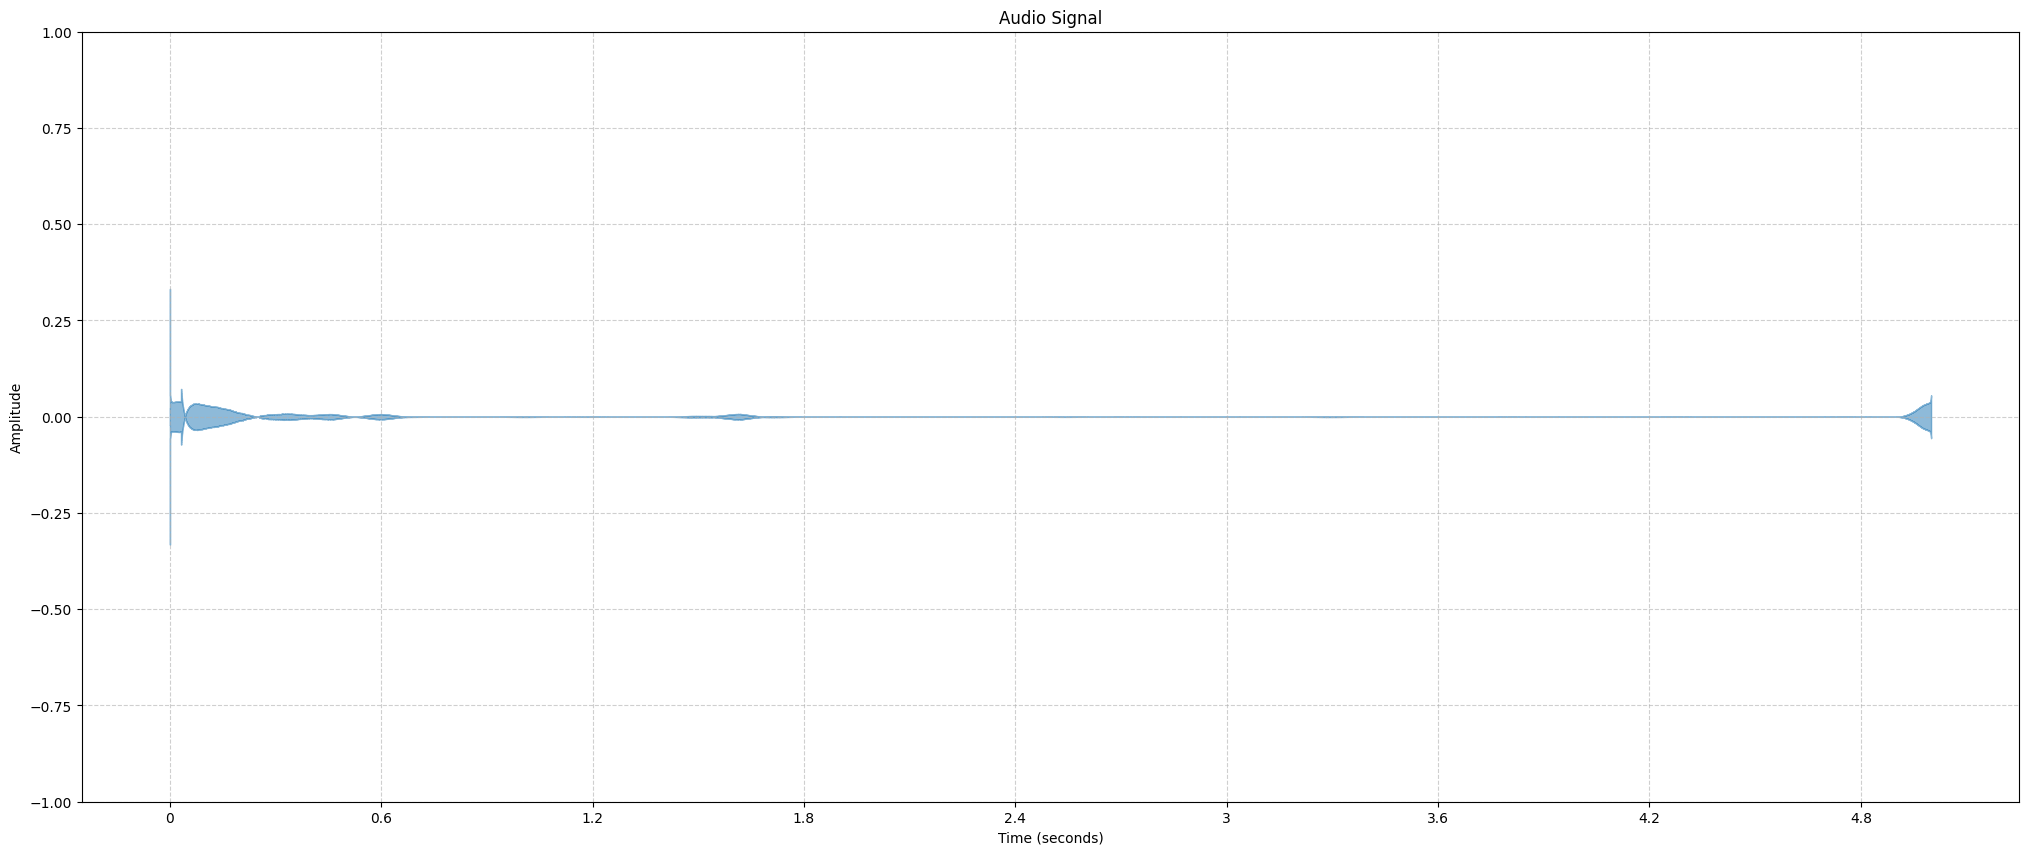

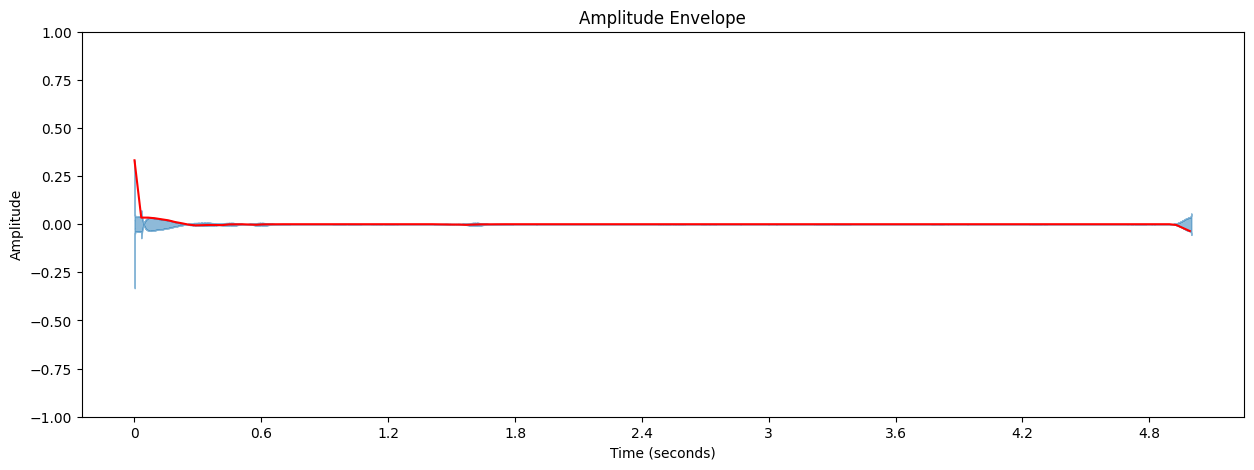

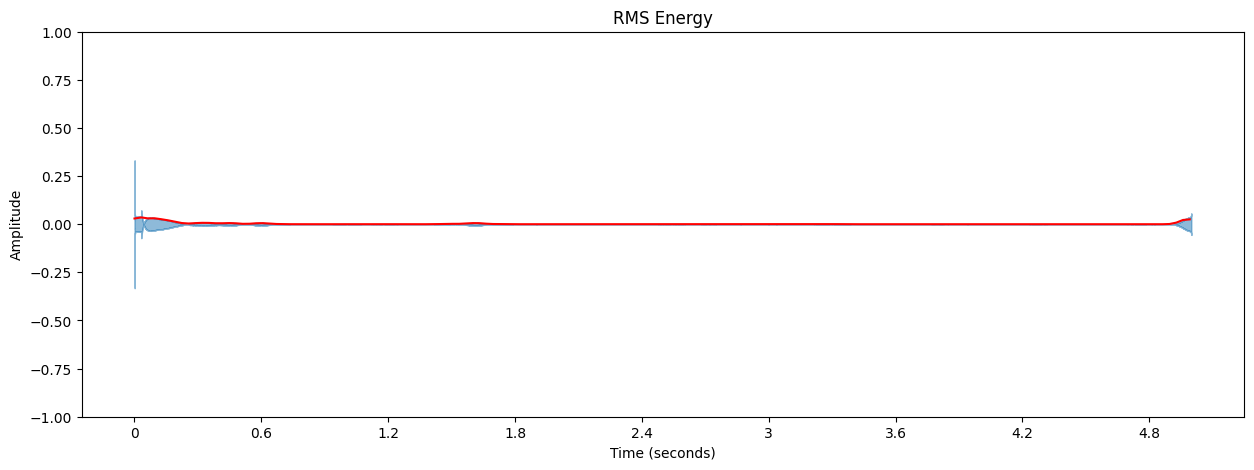

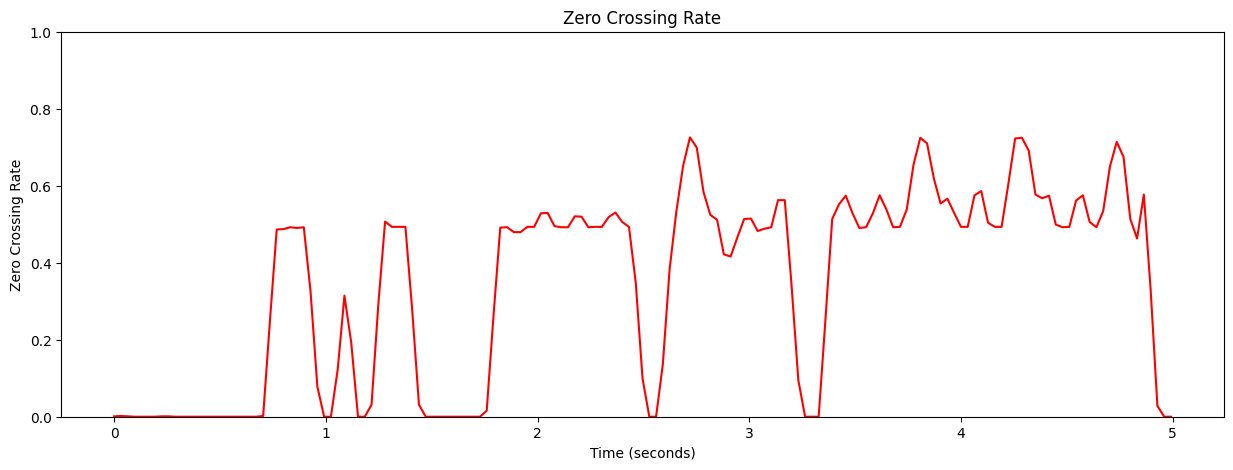

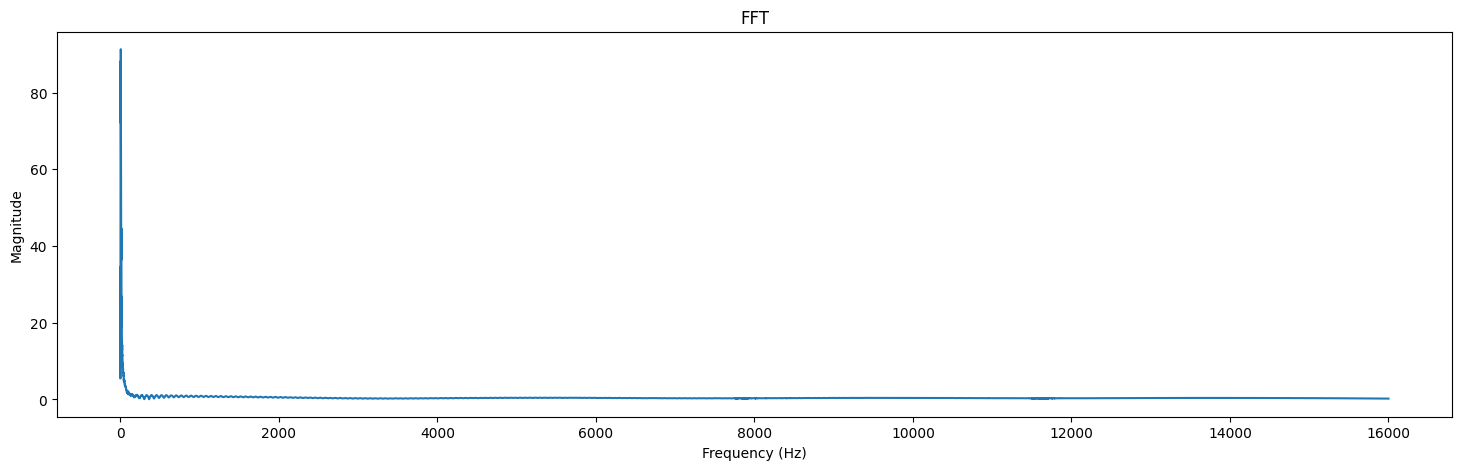

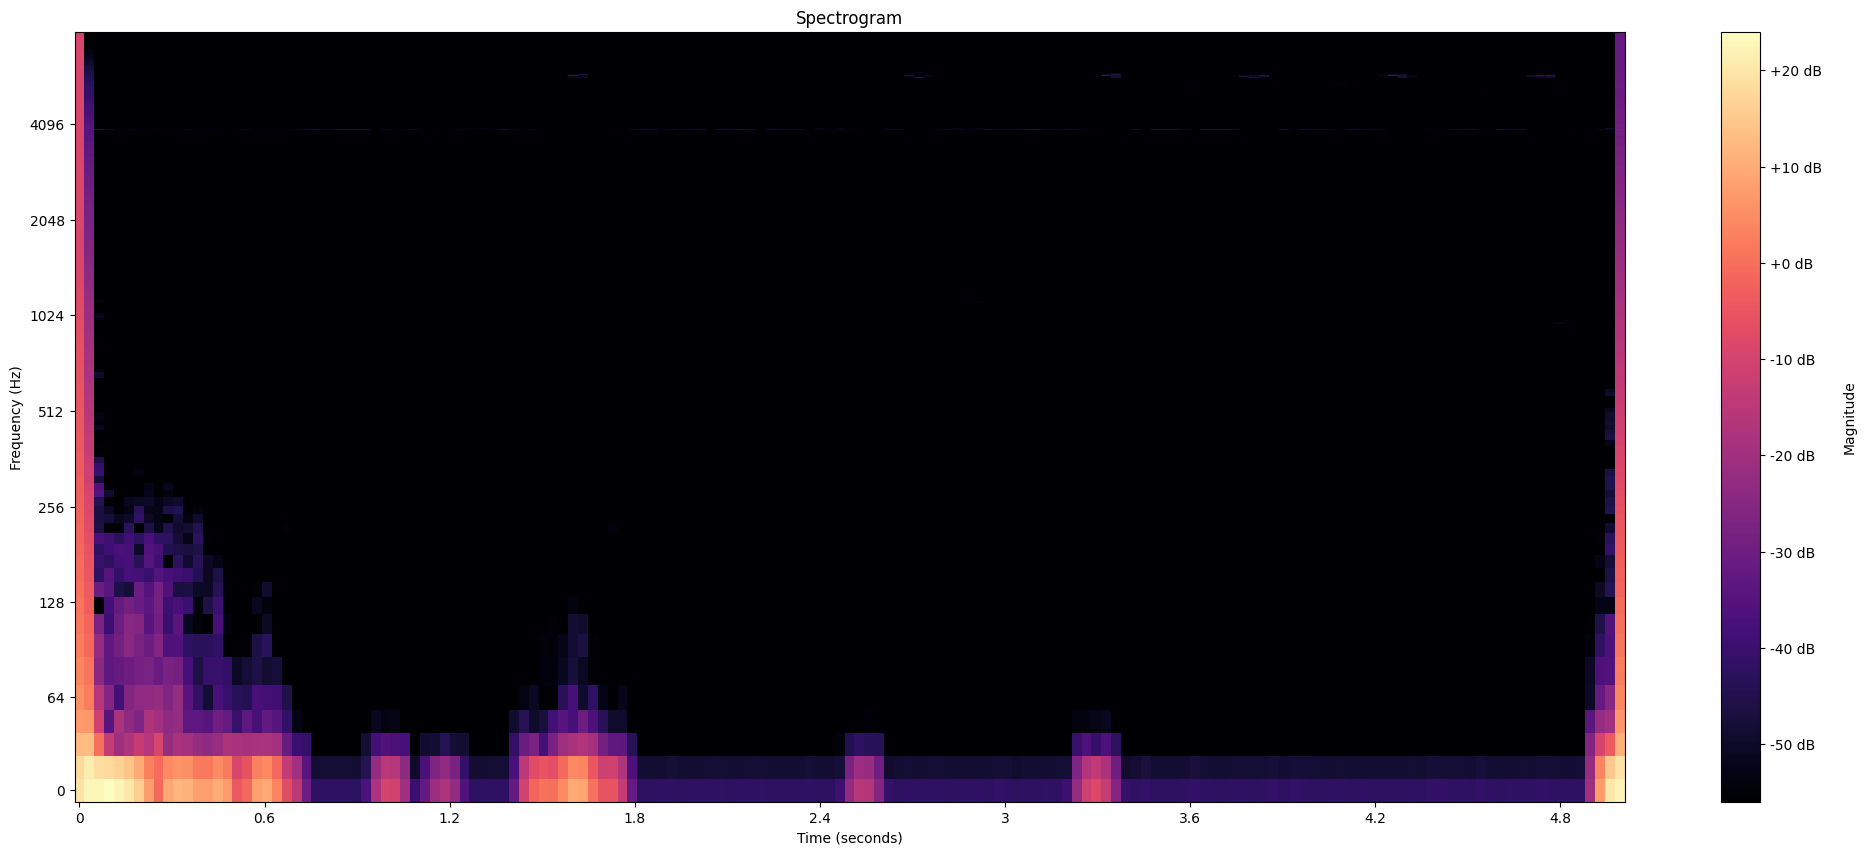

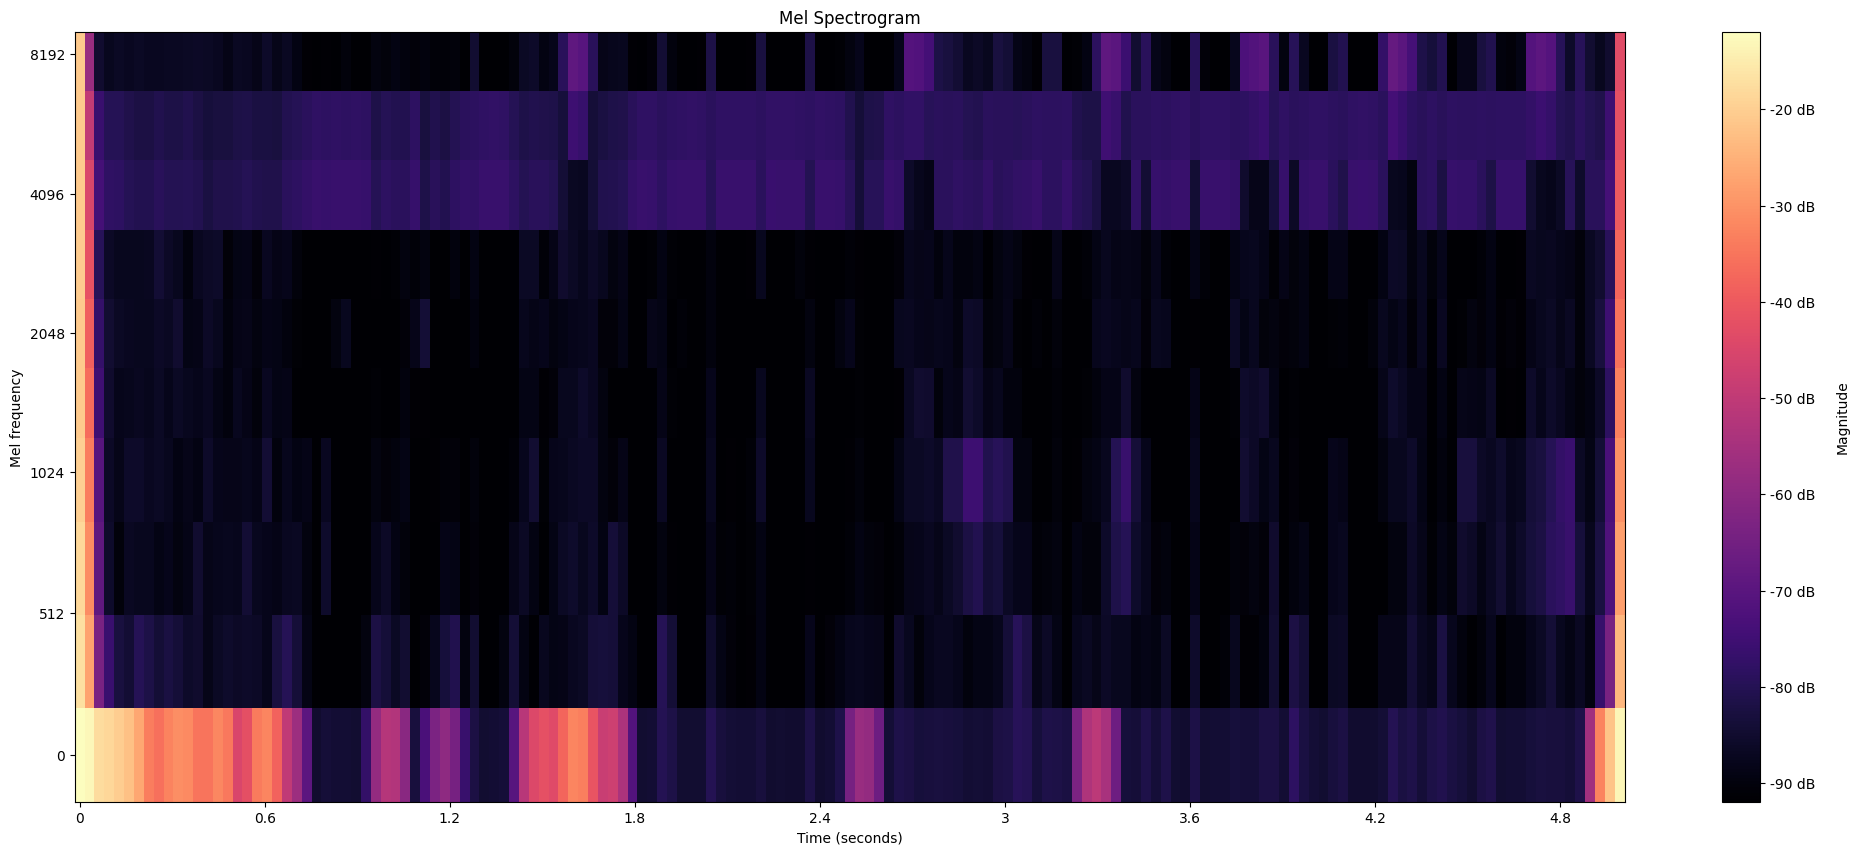

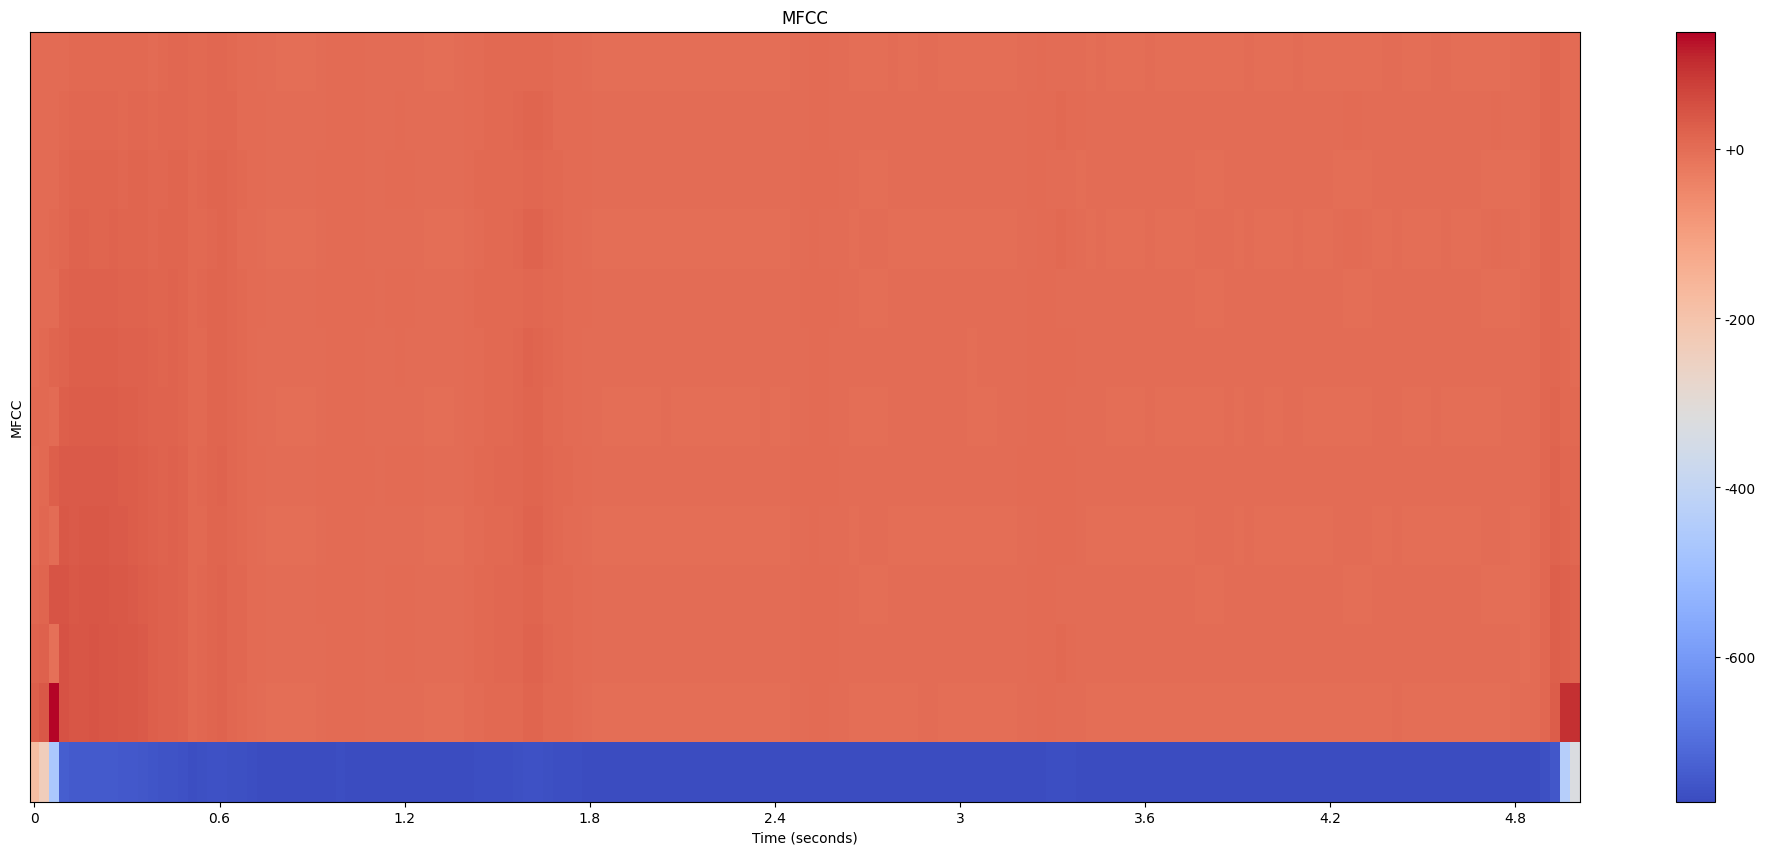

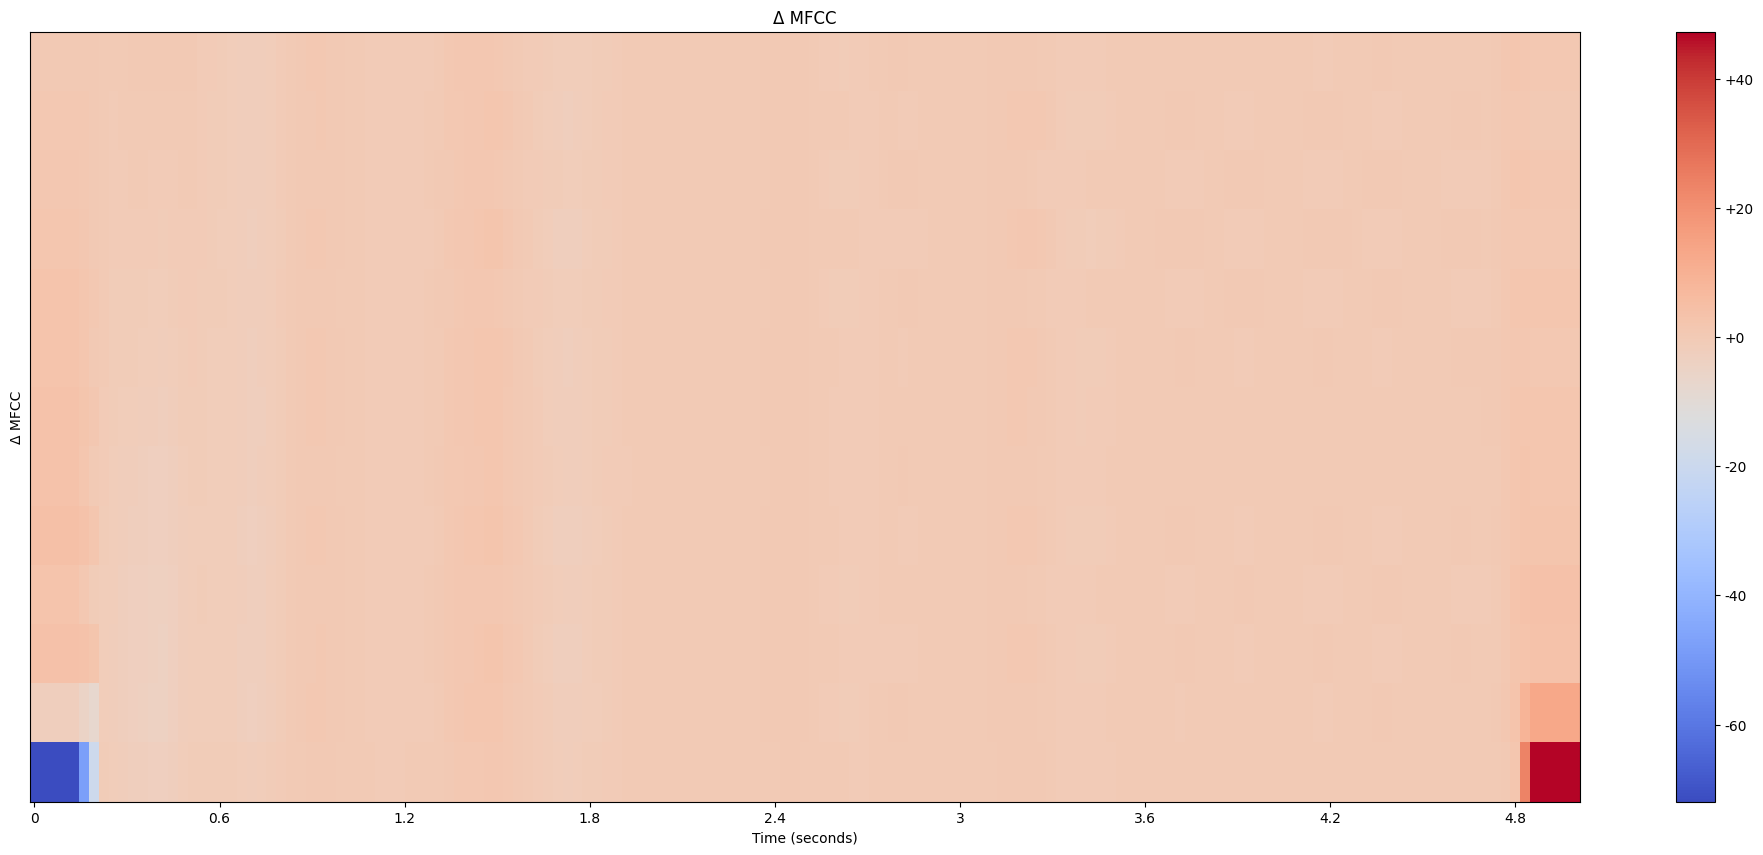

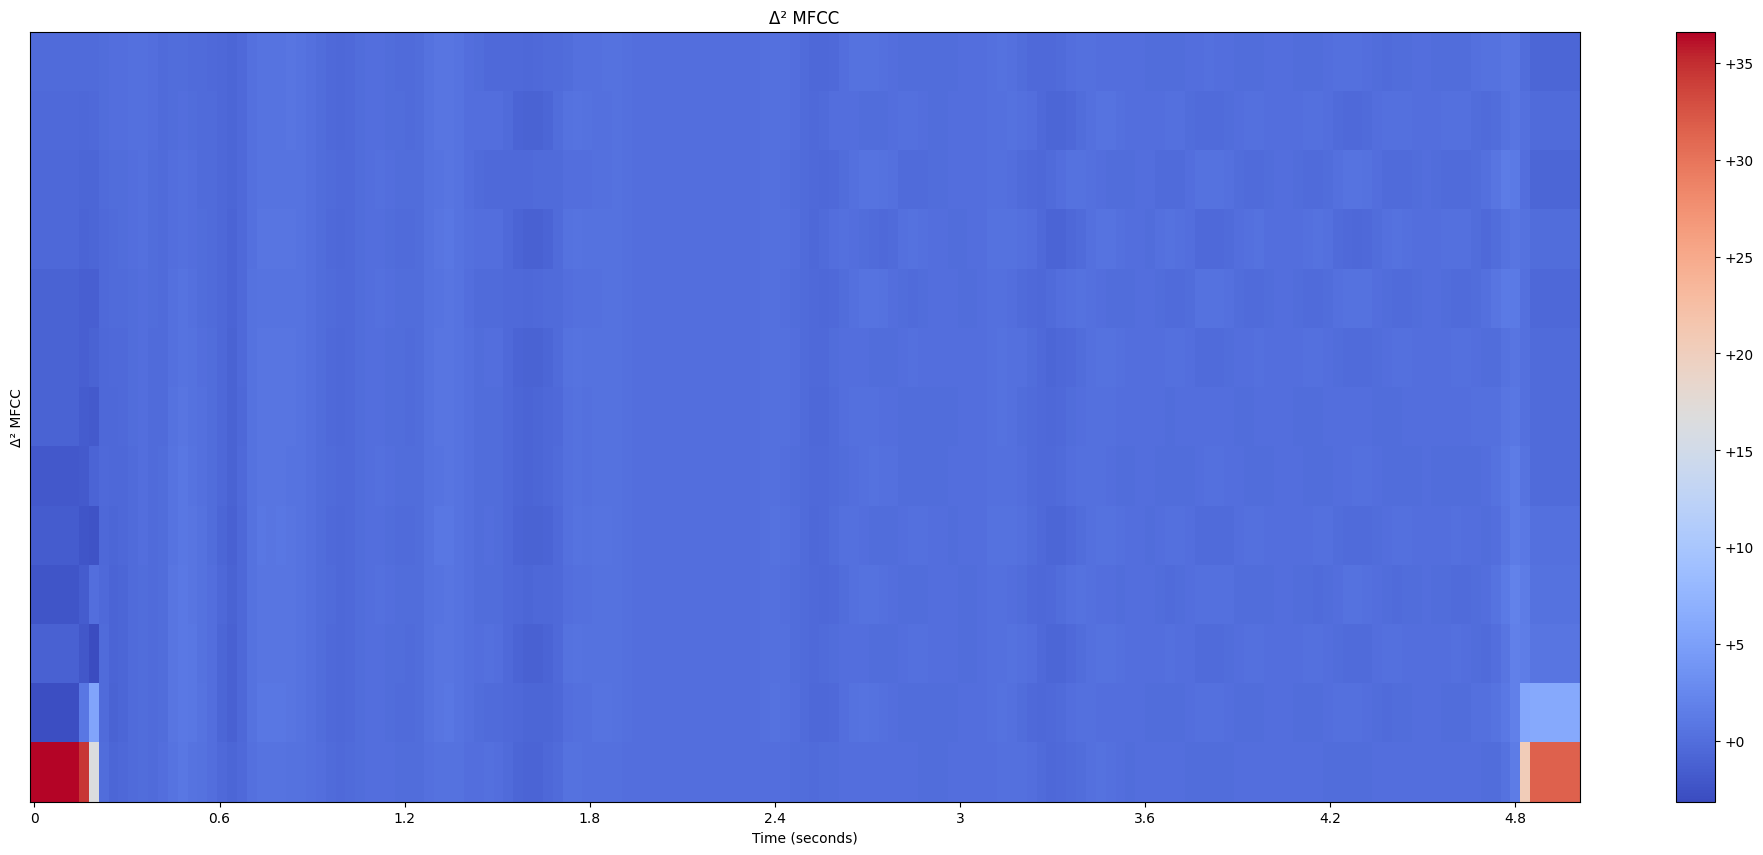

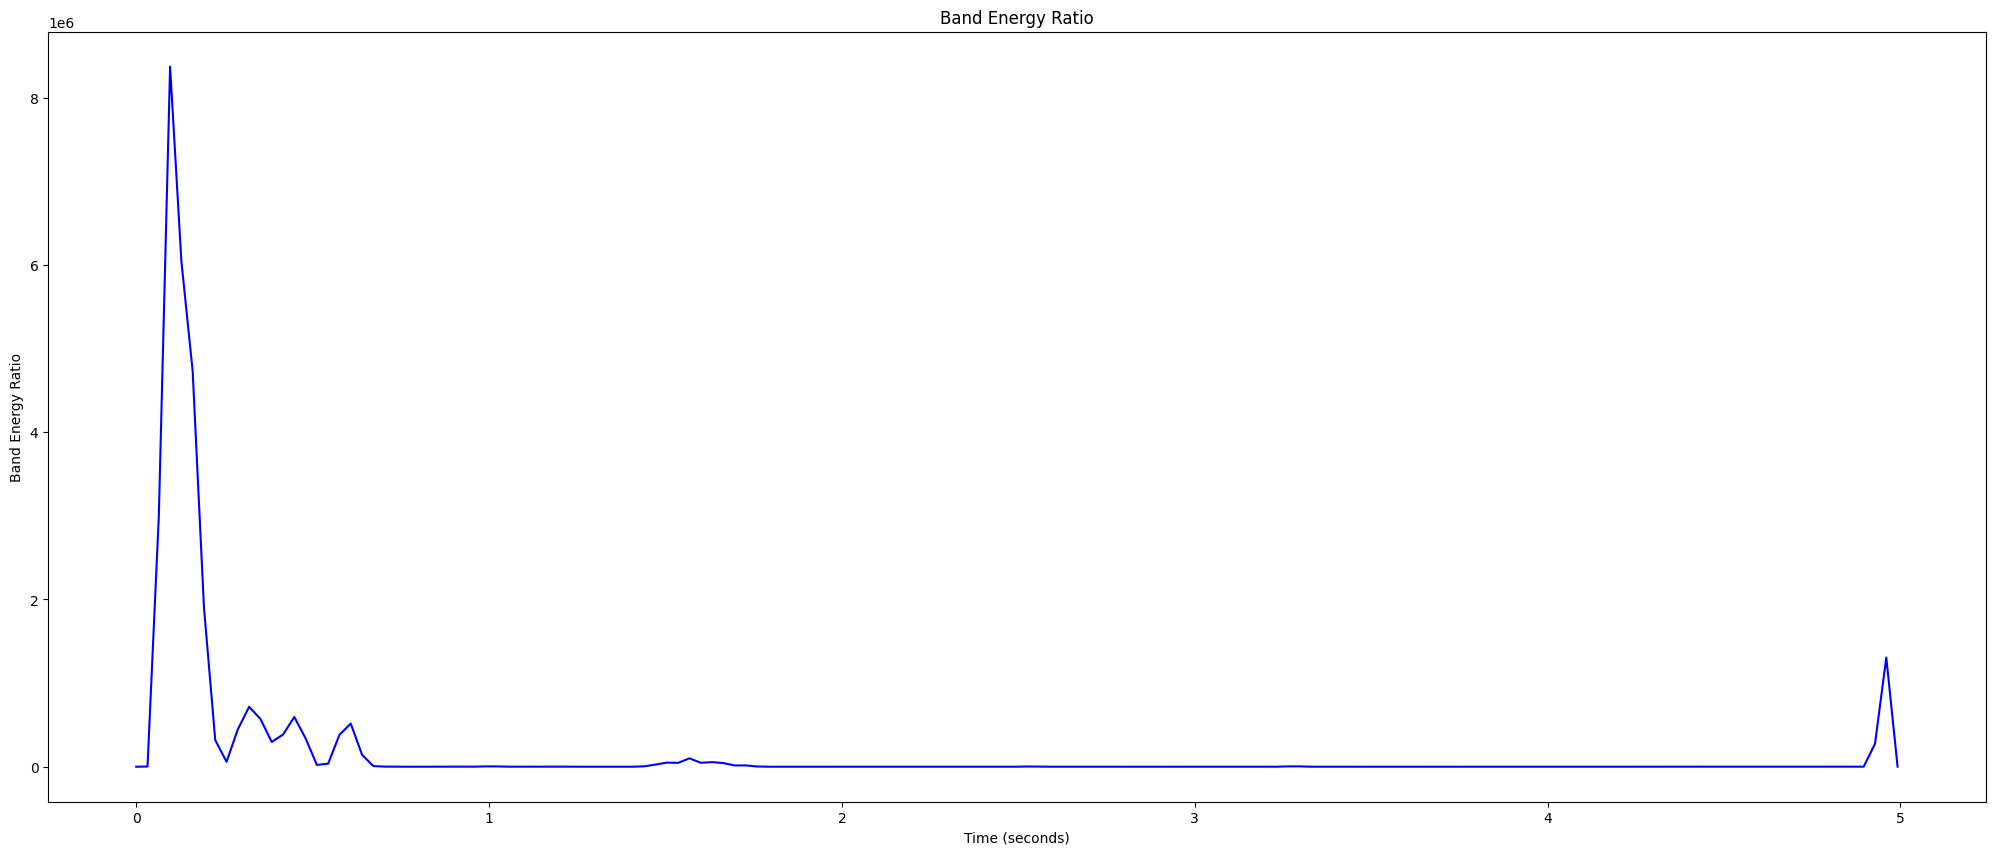

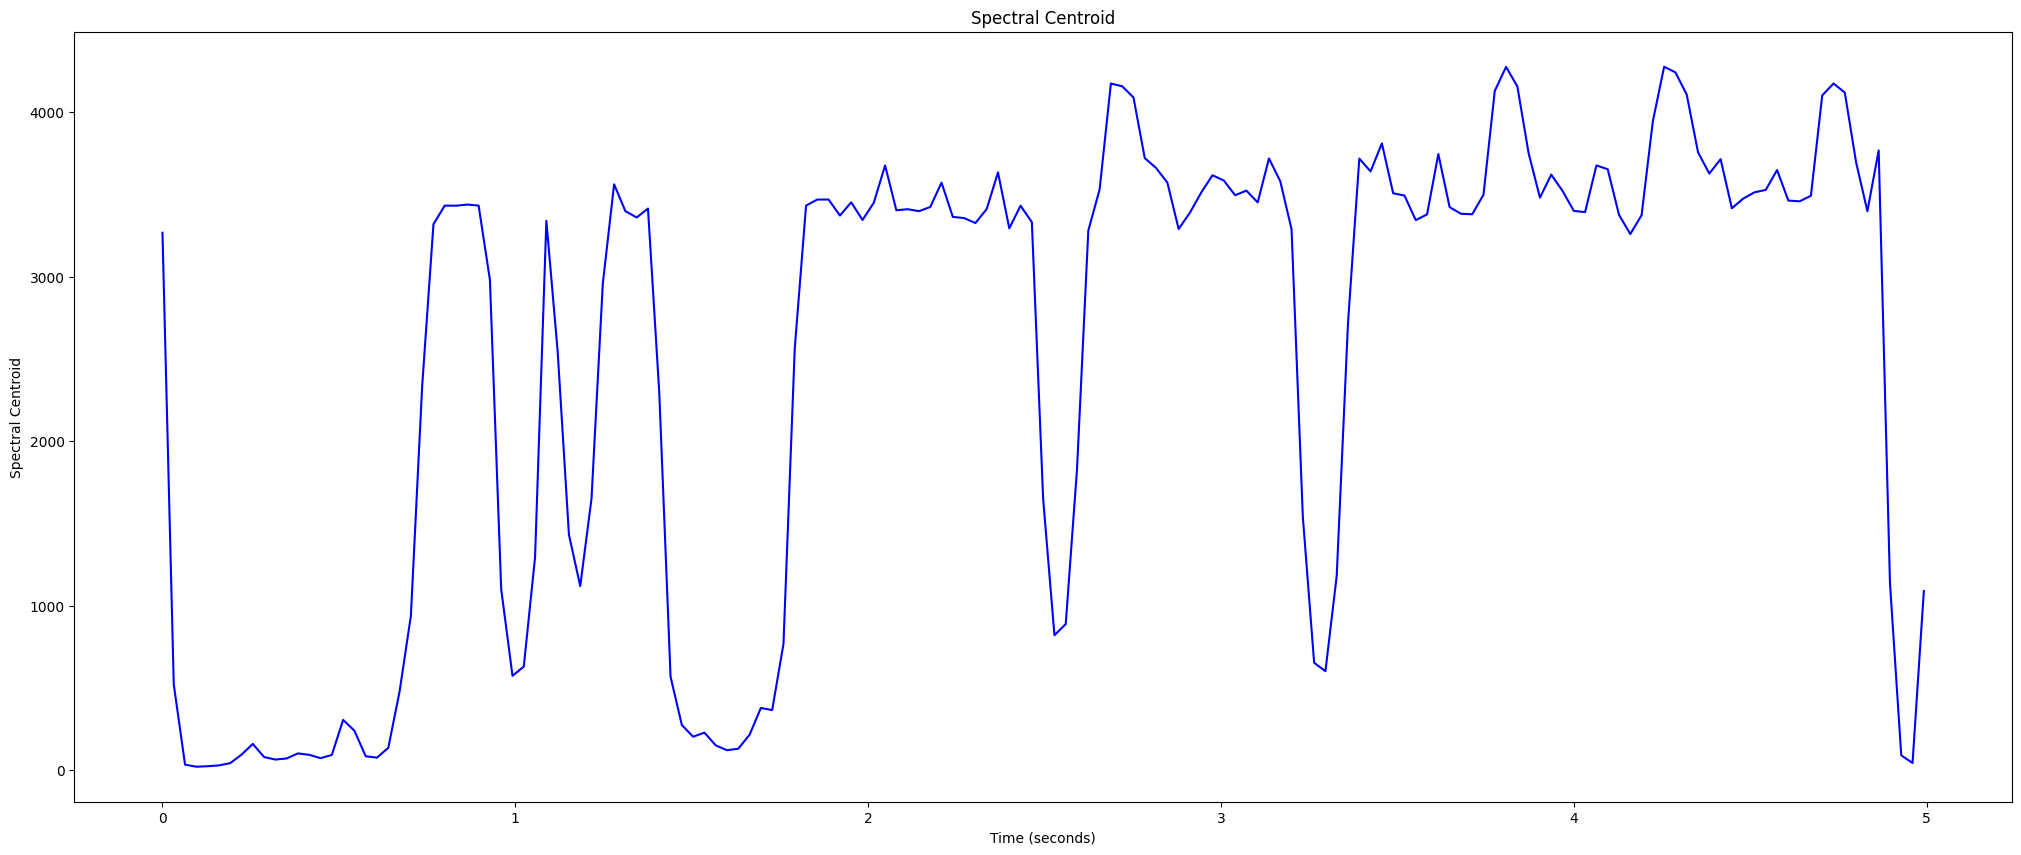

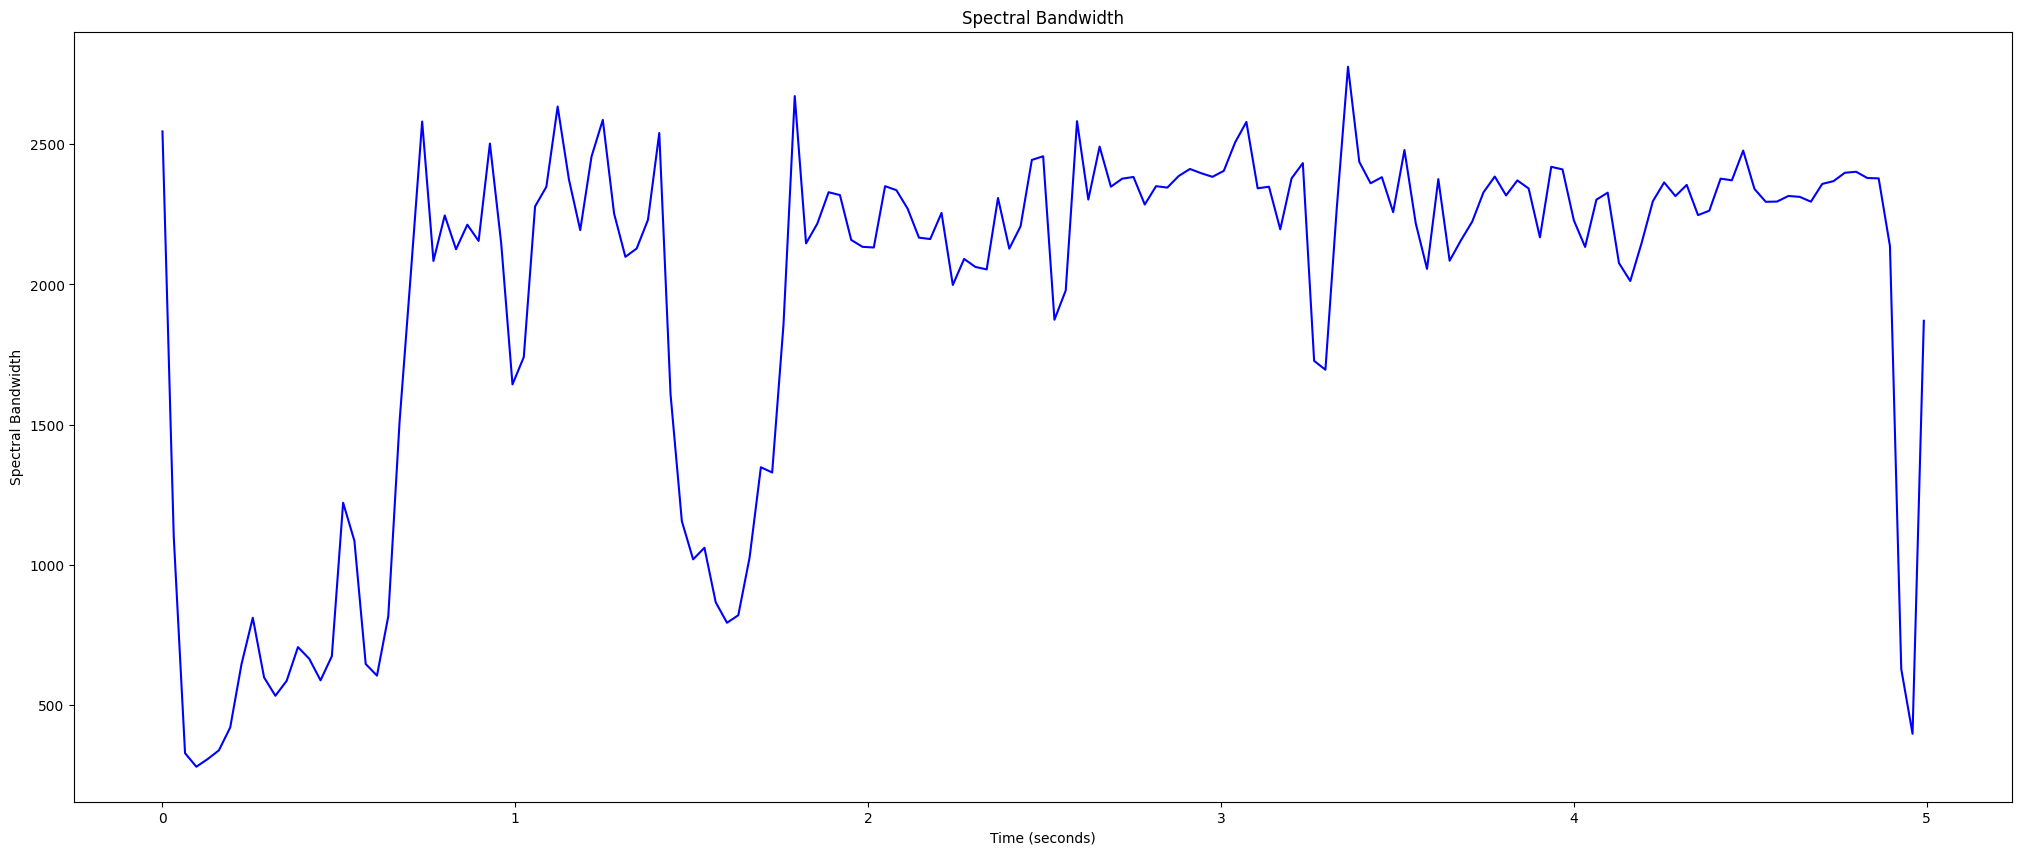

In [30]:
def analyze_single_audio_signal(index):
    entry = audio_signals_metrics[index]
    print(f"Analisi del file: {entry['filename']} con timestamp: {audiofiles_df.loc[index, 'timestamp']}")
    audio_signal, _ = librosa.load(INPUT_AUDIO_DIR / entry["filename"], sr=SAMPLE_RATE)
    ae_audio_signal = entry["amplitude_envelope"]
    rms_audio_signal = entry["rms_energy"]
    zcr_audio_signal = entry["zero_crossing_rate"]
    #magnitude_spectrum_audio_signal = entry["magnitude_spectrum"]
    spectrogram_audio_signal = entry["spectrogram"]
    mel_spectrogram_audio_signal = entry["mel_spectrogram"]
    mfccs = entry["mfccs"]
    delta_mfccs = entry["delta_mfccs"]
    delta2_mfccs = entry["delta2_mfccs"]
    ber_audio_signal = entry["band_energy_ratio"]
    sc_audio_signal = entry["spectral_centroid"]
    bandwidth_audio_signal = entry["spectral_bandwidth"]
    plot_audio_signal(audio_signal, SAMPLE_RATE, title="Audio Signal")
    plot_amplitude_envelope(audio_signal, ae_audio_signal, HOP_LENGTH, SAMPLE_RATE)
    plot_rmse(audio_signal, rms_audio_signal, HOP_LENGTH, SAMPLE_RATE)
    plot_zero_crossing_rate(zcr_audio_signal, HOP_LENGTH, SAMPLE_RATE)
    plot_magnitude_spectrum(audio_signal, SAMPLE_RATE, "FFT")
    plot_spectrogram(spectrogram_audio_signal, SAMPLE_RATE, HOP_LENGTH, y_axis="log")
    plot_spectrogram(mel_spectrogram_audio_signal, SAMPLE_RATE, HOP_LENGTH, y_axis="mel")
    plot_mfcc(mfccs, SAMPLE_RATE, HOP_LENGTH)
    plot_mfcc(delta_mfccs, SAMPLE_RATE, HOP_LENGTH, ylabel="Δ MFCC", title="Δ MFCC")
    plot_mfcc(delta2_mfccs, SAMPLE_RATE, HOP_LENGTH, ylabel="Δ² MFCC", title="Δ² MFCC")
    plot_band_energy_ratio(ber_audio_signal, HOP_LENGTH, SAMPLE_RATE)
    plot_spectral_centroid(sc_audio_signal, HOP_LENGTH, SAMPLE_RATE)
    plot_spectral_bandwidth(bandwidth_audio_signal, HOP_LENGTH, SAMPLE_RATE)


index=81
analyze_single_audio_signal(index)